# Wasserstein Curve Inspection — Real vs Baseline vs Best

Companion notebook to `results_latex_table.ipynb`'s "Complete-Curve Evaluation" section.
That notebook only shows the *aggregated* W1 (time) / W1 (value) numbers — this notebook
answers "what does that actually look like": for one process, it

1. Trains genuine **Baseline** (median/barycenter-per-activity) and **Best**
   (DTW + External Factors + Previous-Activity) pipelines, live, on that process's real
   training data — same functions the main pipeline uses (`sim_extractor.py`), scoped to
   one sensor. **One pipeline per activity**, matching how the production pipeline
   actually trains (`_train_curve_only_worker` runs one worker per (sensor, activity,
   object) combo) — a sensor is often only active during a couple of activities and ~0
   for the rest, so a single pipeline pooling all activities together would blend a
   degenerate near-zero barycenter with the real signal and predict garbage.
2. Evaluates both on real **held-out test curves** (per-activity-instance), with the same
   z-scored sMAE used in the approach-comparison boxplot, and plots Actual vs Baseline vs
   Best for a few instances.
3. Reconstructs a handful of **complete real test cases** (every activity concatenated in
   real time order) and overlays the real curve against both models' predictions for that
   whole case, computing the *exact same* `wasserstein_time` / `wasserstein_value` metrics
   used in the results notebook — so you can see directly what a given W1 number corresponds
   to visually.

Note on step 3: to show a *complete*, gap-free case we predict every activity in the case,
including any that happened to land in the training split for this sensor (curves are
split per-activity-instance, not per-case, so a single case can straddle both splits).
That's fine for visual intuition but isn't a strict held-out test — step 2 is the rigorous
comparison.


In [1]:
# -- Config --------------------------------------------------------------------
PROCESS = 'process_1'   # change this to inspect a different process
SENSOR  = None          # None = auto-pick the first modelled sensor; or set explicitly, e.g.
                        # 'bottling_power_kW_energy_to_model'
N_EXAMPLE_CASES = 3     # how many real test cases to reconstruct in the complete-curve view
TEST_SIZE    = 0.15     # same default as the main pipeline's curve-only training
RANDOM_STATE = 42
MIN_CURVES_PER_ACTIVITY = 10  # skip (activity, this sensor) combos with too few curves or zero variance


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from scipy.stats import wasserstein_distance

import sys
sys.path.insert(0, '.')
from sim_extractor import (
    split_curves_with_prev_activity,
    build_and_train_pipeline,
    build_and_train_pipeline_exog_prev_activity,
    predict_raw_curve,
    predict_raw_curve_exog_prev_activity,
    _extract_real_case_curves_all_sensors,
)

pd.set_option('display.max_columns', 50)


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## 1. Load the real data and pick a sensor

`df_expanded.parquet` is the per-timestep real energy data — the same input the full
pipeline trains on — independent of any specific experiment run, so this works even
without re-running `modelling.py`.


In [3]:
data_path = Path('..') / 'data' / 'gold' / 'experiment_1' / PROCESS / 'datasets' / 'df_expanded.parquet'
df_expanded = pd.read_parquet(data_path)

sensors = [c for c in df_expanded.columns
           if c.endswith('_to_model') and df_expanded[c].dtype in ('float64', 'float32', 'int64', 'int32')]
activities = df_expanded['activity_log'].dropna().unique().tolist()
if 'object_log' in df_expanded.columns and df_expanded['object_log'].notna().any():
    objects = df_expanded['object_log'].dropna().unique().tolist()
else:
    objects = ['_all_']
ef_cols = [c for c in df_expanded.columns
           if c.startswith('ef_') and df_expanded[c].dtype in ('float64', 'float32', 'int64', 'int32')]

if SENSOR is None:
    SENSOR = sensors[0]

print(f'Process          : {PROCESS}')
print(f'Sensors available: {sensors}')
print(f'Using sensor     : {SENSOR}')
print(f'Activities       : {activities}')
print(f'Objects          : {objects}')
print(f'External factors : {ef_cols}')
print(f'Rows in df_expanded: {len(df_expanded)}')


Process          : process_1
Sensors available: ['destillation_steam_demand_kW_energy_to_model', 'destillation_cooling_demand_kW_energy_to_model', 'autoclave_steam_demand_kW_energy_to_model', 'autoclave_cooling_water_demand_kW_energy_to_model', 'bottling_power_kW_energy_to_model', 'individual_packaging_power_kW_energy_to_model', 'water_supply_power_kW_energy_to_model']
Using sensor     : destillation_steam_demand_kW_energy_to_model
Activities       : ['water_supply_prepare', 'water_supply_working', 'destillation_preparation', 'destillation_production', 'destillation_emptying', 'bottling_prepare', 'bottling_working', 'bottling_cool', 'autoclaving_2_prepare', 'autoclaving_2_heat', 'autoclaving_2_hold', 'autoclaving_2_cool', 'individual_packaging_prepare', 'individual_packaging_working', 'autoclaving_1_prepare', 'autoclaving_1_heat', 'autoclaving_1_hold', 'autoclaving_1_cool', 'autoclaving_3_prepare', 'autoclaving_3_heat', 'autoclaving_3_hold', 'autoclaving_3_cool']
Objects          : ['w

## 2. Train real Baseline and Best pipelines, per activity

`split_curves_with_prev_activity` does the real train/test split (per activity-instance,
same as the main pipeline) and attaches previous-activity + external-factor context to
every curve. We then group the train curves by activity and train one Baseline + one Best
pipeline **per activity** (matching production), skipping activities where this sensor is
always ~0 (nothing to model there — both real and predicted will correctly show ~0).


In [4]:
train_curves, test_curves = split_curves_with_prev_activity(
    df_expanded, SENSOR, activities, objects,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, verbose=0,
    exog_columns=ef_cols,
)
print(f'{len(train_curves)} train curves, {len(test_curves)} test curves for {SENSOR}')

train_by_activity = defaultdict(list)
for c in train_curves:
    train_by_activity[c['activity']].append(c)

relevant_activities = [
    act for act, cs in train_by_activity.items()
    if len(cs) >= MIN_CURVES_PER_ACTIVITY
    and np.std(np.concatenate([c['original_values'] for c in cs])) > 1e-6
]
print(f'Activities with real signal for {SENSOR}: {relevant_activities}')

baseline_pipelines = {}
best_pipelines = {}
for act in relevant_activities:
    cs = train_by_activity[act]
    baseline_pipelines[act] = build_and_train_pipeline(cs, SENSOR, verbose=0)
    best_pipelines[act] = build_and_train_pipeline_exog_prev_activity(cs, SENSOR, verbose=0)
    print(f"  [{act}] {len(cs)} train curves | Best model: {best_pipelines[act]['model_name']}  val_mae={best_pipelines[act]['val_mae']:.3f}")

def predict_baseline(raw, act, attrs):
    if act in baseline_pipelines:
        return predict_raw_curve(raw, act, attrs, baseline_pipelines[act])
    return np.zeros_like(raw, dtype=float)

def predict_best(raw, act, attrs, exog):
    if act in best_pipelines:
        return predict_raw_curve_exog_prev_activity(raw, act, attrs, best_pipelines[act], exog_values=exog)
    return np.zeros_like(raw, dtype=float)


1989 train curves, 352 test curves for destillation_steam_demand_kW_energy_to_model
Activities with real signal for destillation_steam_demand_kW_energy_to_model: ['destillation_production', 'destillation_preparation']
  [destillation_production] 258 train curves | Best model: Gradient Boosting  val_mae=14.417
  [destillation_preparation] 26 train curves | Best model: Gradient Boosting  val_mae=4.858


## 3. Instance-level held-out evaluation (sMAE)

Same z-scored per-instance metric used in the approach-comparison boxplot
(`sim_extractor.evaluate_pipeline_on_test`): z-score the real curve and the prediction
against *that instance's own* mean/std, then mean absolute z-score error. This is the
strict, fully held-out comparison — every curve here came from the test split and was
never seen during training. Restricted to test instances whose activity has a trained
pipeline (the "always ~0" activities are excluded here since sMAE is undefined for a
zero-variance real curve anyway — see the coefficient-of-variation guard below).


In [5]:
def smae(actual, pred):
    mu, sig = actual.mean(), actual.std()
    if sig < 1e-10 or (mu != 0 and (sig / abs(mu)) <= 0.01):
        return np.nan
    zt, zp = (actual - mu) / sig, (pred - mu) / sig
    return float(np.mean(np.abs(zt - zp)))

instance_records = []
instance_preds = {}
for c in test_curves:
    if c['activity'] not in baseline_pipelines:
        continue
    raw = c['original_values']
    attrs = c['attributes']
    exog = c.get('exog_values', {})
    base_pred = predict_baseline(raw, c['activity'], attrs)
    best_pred = predict_best(raw, c['activity'], attrs, exog)
    instance_preds[c['instance_id']] = (raw, base_pred, best_pred, c['activity'])
    instance_records.append({
        'instance_id':   c['instance_id'],
        'activity':      c['activity'],
        'n_points':      len(raw),
        'sMAE_baseline': smae(raw, base_pred),
        'sMAE_best':     smae(raw, best_pred),
    })

df_instances = pd.DataFrame(instance_records).sort_values('sMAE_best')
print(f"median sMAE -- baseline: {df_instances['sMAE_baseline'].median():.3f}   best: {df_instances['sMAE_best'].median():.3f}")
display(df_instances)


median sMAE -- baseline: 0.627   best: 0.673


,instance_id,activity,n_points,sMAE_baseline,sMAE_best
30,2160,destillation_preparation,5,0.073526,0.068050
12,3644,destillation_preparation,5,0.097790,0.215969
42,449,destillation_production,24,0.553933,0.592675
1,917,destillation_production,29,0.527892,0.599112
16,3402,destillation_production,19,0.590554,0.601089
35,1908,destillation_production,20,0.617919,0.611487
24,3815,destillation_production,32,0.577810,0.612014
10,1656,destillation_production,38,0.551833,0.615023
29,1189,destillation_production,22,0.607926,0.618753
15,2739,destillation_production,10,0.672031,0.623458


## 4. Plot: Real vs Baseline vs Best, a few held-out test instances

Best and worst (by `sMAE_best`) instances, so you can see both a case the model nails and
one it struggles with.


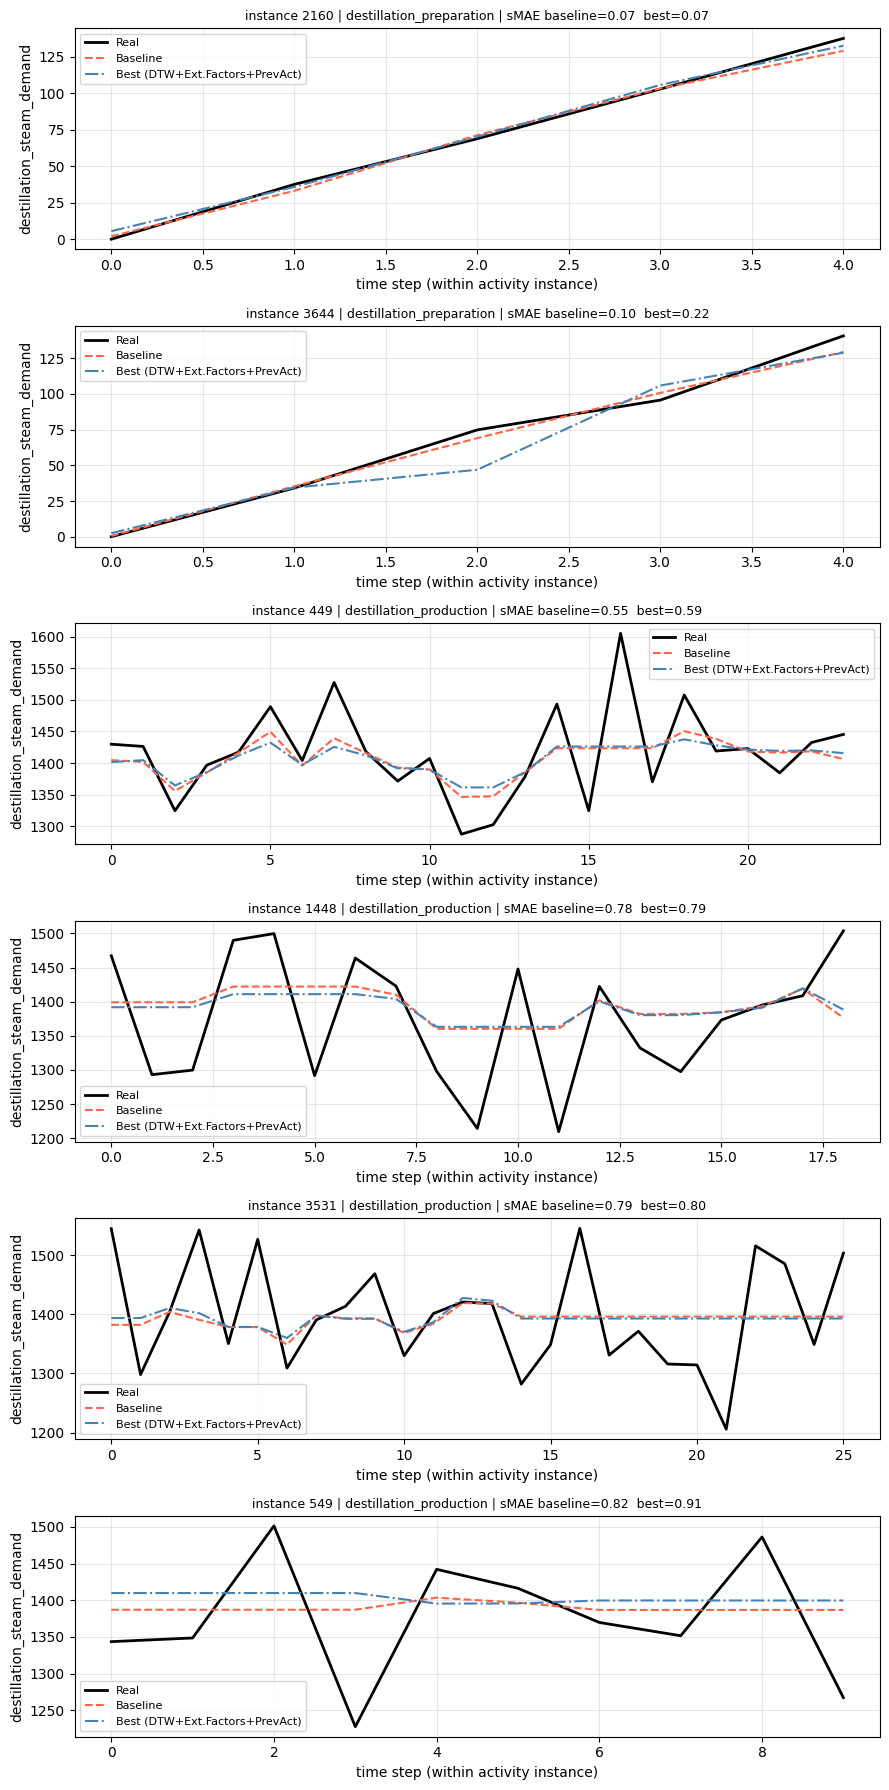

In [6]:
_n_show = min(3, len(df_instances))
_show_ids = pd.concat([df_instances.head(_n_show), df_instances.tail(_n_show)])['instance_id'].tolist()

_n = len(_show_ids)
_fig, _axes = plt.subplots(_n, 1, figsize=(9, 3 * max(_n, 1)))
_axes = np.atleast_1d(_axes)
for _ax, _iid in zip(_axes, _show_ids):
    raw, base_pred, best_pred, act = instance_preds[_iid]
    _ax.plot(raw, label='Real', color='black', linewidth=2)
    _ax.plot(base_pred, label='Baseline', color='tomato', linestyle='--', linewidth=1.5)
    _ax.plot(best_pred, label='Best (DTW+Ext.Factors+PrevAct)', color='steelblue', linestyle='-.', linewidth=1.5)
    _row = df_instances[df_instances['instance_id'] == _iid].iloc[0]
    _ax.set_title(f"instance {_iid} | {act} | sMAE baseline={_row['sMAE_baseline']:.2f}  best={_row['sMAE_best']:.2f}", fontsize=9)
    _ax.set_xlabel('time step (within activity instance)')
    _ax.set_ylabel(SENSOR.split('_kW')[0].split('_energy')[0])
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Complete-case reconstruction: Real vs Baseline vs Best

For a few real test cases, concatenate every activity in the case (real time order) and
overlay:
- **Real** — the case's actual sensor readings (`_extract_real_case_curves_all_sensors`,
  the same function `compare_complete_case_curves` uses in production).
- **Baseline** / **Best** — each activity segment predicted with the per-activity
  pipelines trained above, using that segment's *own real* values only for DTW-decode
  positioning/length (never as a leaked target) and, for Best, the real previous-activity
  stats computed by walking the case chronologically. Segments whose activity has no
  trained pipeline for this sensor (always ~0) are predicted as 0, matching reality.

Then computes `wasserstein_time` / `wasserstein_value` for this one case exactly as the
production metric does, so the number and the picture are directly tied together.

**Important scale caveat**: this reconstruction places every predicted segment on the
case's own *real* activity timeline (real durations, real activity order). The production
`complete_curve_eval_results` numbers instead compare against a *simulated* case (from a
process-mining + duration-prediction pipeline), whose activity durations/order can differ
from the real case's. That means the `wasserstein_time`/`wasserstein_value` values below
will typically read much smaller than the aggregate table in section 6 — they isolate pure
curve-shape/value error, with no duration-prediction or control-flow-simulation error mixed
in. Don't compare the magnitudes directly against section 6; compare Baseline vs Best
*within* this section instead.


In [7]:
def build_case_predictions(case_id, sensor, ef_cols):
    """Chronologically walk one case's activity instances, predicting each with both
    (per-activity) pipelines. Returns (t_base, v_base, t_best, v_best) in case-relative
    minutes."""
    d = df_expanded[df_expanded['case_id_log'] == case_id].copy()
    d['timestamp_start_log'] = pd.to_datetime(d['timestamp_start_log'])
    d['datetime_energy'] = pd.to_datetime(d['datetime_energy'])
    d = d.sort_values(['timestamp_start_log', 'datetime_energy'])
    case_start = d['timestamp_start_log'].min()

    obj_col = 'object_log' if 'object_log' in d.columns else None
    group_cols = ['activity_log', 'timestamp_start_log'] + ([obj_col] if obj_col else [])

    prev_stats = {'prev_act_name': 'none', 'prev_act_mean': 0.0, 'prev_act_std': 0.0,
                  'prev_act_max': 0.0, 'prev_act_end': 0.0, 'prev_act_length': 0.0}

    t_base, v_base, t_best, v_best = [], [], [], []
    for _keys, g in d.groupby(group_cols, sort=False):
        g = g.sort_values('datetime_energy')
        raw = g[sensor].dropna().values.astype(float)
        if len(raw) < 2:
            continue
        act = g['activity_log'].iloc[0]
        raw_attrs = g['object_attributes_log'].iloc[0] if 'object_attributes_log' in g.columns else {}
        attrs = dict(raw_attrs) if isinstance(raw_attrs, dict) else {}
        ts = pd.to_datetime(g['timestamp_start_log'].iloc[0])
        attrs['hour_of_day'] = float(ts.hour)
        attrs['day_of_week'] = float(ts.dayofweek)
        attrs.update(prev_stats)
        exog_vals = {c: g[c].values for c in ef_cols if c in g.columns}

        t_seg = (g['datetime_energy'] - case_start).dt.total_seconds().values / 60.0

        base_pred = predict_baseline(raw, act, attrs)
        best_pred = predict_best(raw, act, attrs, exog_vals)

        t_base.append(t_seg); v_base.append(base_pred)
        t_best.append(t_seg); v_best.append(best_pred)

        prev_stats = {
            'prev_act_name':   act,
            'prev_act_mean':   float(np.mean(raw)),
            'prev_act_std':    float(np.std(raw)) if len(raw) >= 2 else 0.0,
            'prev_act_max':    float(np.max(raw)),
            'prev_act_end':    float(raw[-1]),
            'prev_act_length': float(len(raw)),
        }

    return (np.concatenate(t_base), np.concatenate(v_base),
            np.concatenate(t_best), np.concatenate(v_best))


In [8]:
# Pick example cases at random (deterministic seed), restricted to cases with a handful
# of activity instances for this sensor so the plot is legible. This section is for visual
# intuition (see note above) -- section 3/4 above is the strict held-out comparison.
_case_counts = (
    df_expanded[df_expanded[SENSOR].notna()]
    .groupby('case_id_log')['timestamp_start_log']
    .nunique()
)
_eligible_cases = _case_counts[(_case_counts >= 2) & (_case_counts <= 30)].index.tolist()

rng = np.random.default_rng(RANDOM_STATE)
example_case_ids = rng.choice(_eligible_cases, size=min(N_EXAMPLE_CASES, len(_eligible_cases)), replace=False)
print(f'Example case_ids: {list(example_case_ids)}')


Example case_ids: [np.str_('batch_197'), np.str_('batch_027'), np.str_('batch_232')]


In [9]:
def w1_metrics_for_case(case_id, sensor):
    """Exactly mirrors compare_complete_case_curves' per-case W1 computation."""
    case_df = df_expanded[df_expanded['case_id_log'] == case_id]
    real_curves = _extract_real_case_curves_all_sensors(case_df, [sensor])
    t_real, v_real = real_curves[sensor]

    t_base, v_base, t_best, v_best = build_case_predictions(case_id, sensor, ef_cols)

    w_real = np.clip(v_real, 0, None)
    w_base = np.clip(v_base, 0, None)
    w_best = np.clip(v_best, 0, None)

    metrics = {
        'baseline_w1_time':  float(wasserstein_distance(t_real, t_base, u_weights=w_real, v_weights=w_base)),
        'baseline_w1_value': float(wasserstein_distance(v_real, v_base)),
        'best_w1_time':      float(wasserstein_distance(t_real, t_best, u_weights=w_real, v_weights=w_best)),
        'best_w1_value':     float(wasserstein_distance(v_real, v_best)),
    }
    return (t_real, v_real, t_base, v_base, t_best, v_best), metrics


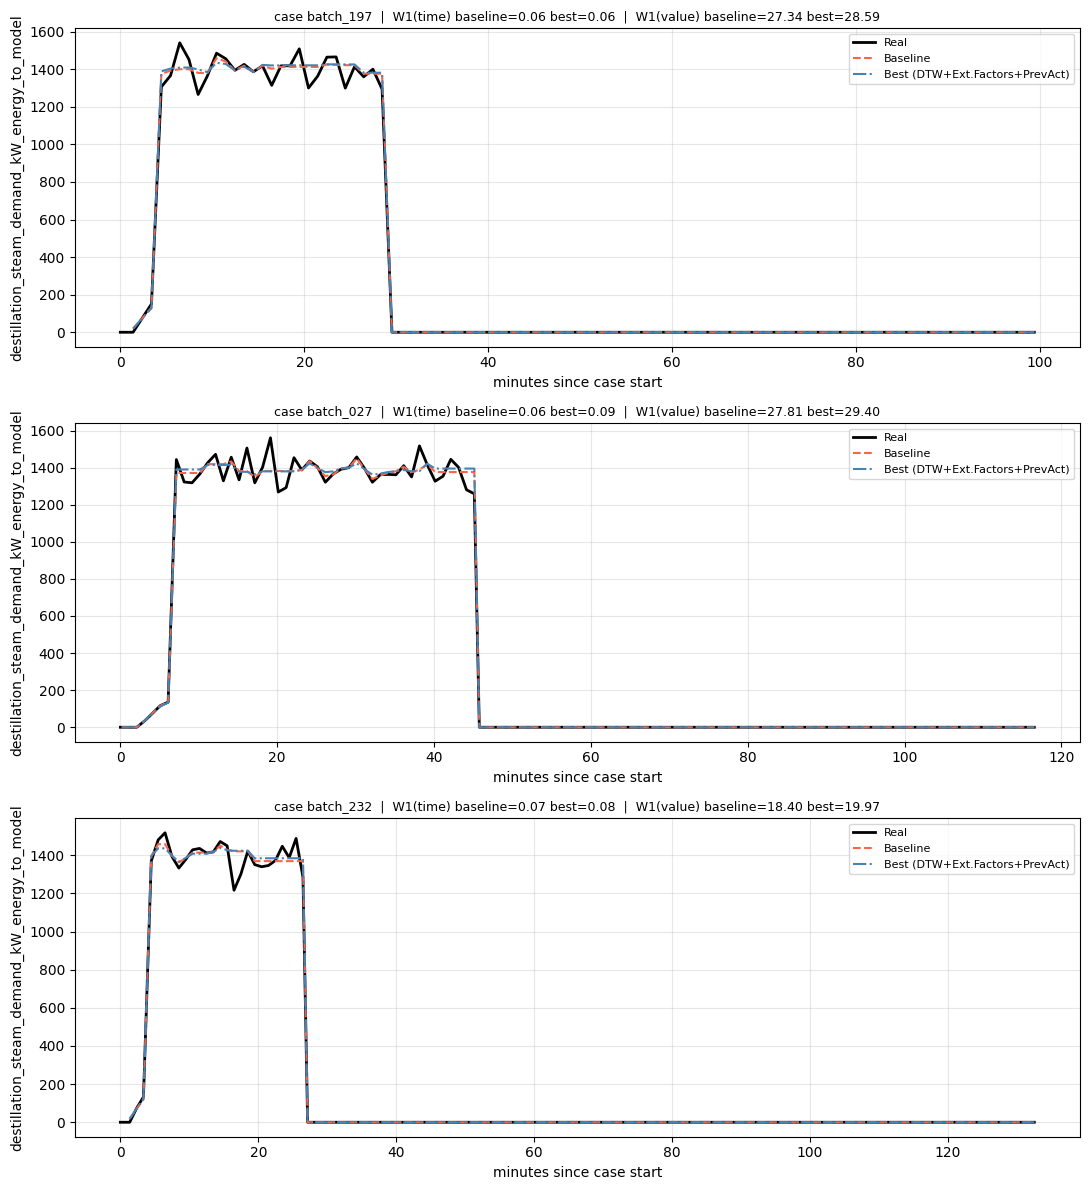

,baseline_w1_time,baseline_w1_value,best_w1_time,best_w1_value
case_id,,,,
batch_197,0.060327,27.339510,0.062489,28.592631
batch_027,0.062670,27.812807,0.087822,29.396141
batch_232,0.067213,18.395195,0.076015,19.966007


In [10]:
_fig, _axes = plt.subplots(len(example_case_ids), 1, figsize=(11, 4 * len(example_case_ids)))
_axes = np.atleast_1d(_axes)

case_w1_rows = []
for _ax, cid in zip(_axes, example_case_ids):
    (t_real, v_real, t_base, v_base, t_best, v_best), metrics = w1_metrics_for_case(cid, SENSOR)
    metrics['case_id'] = cid
    case_w1_rows.append(metrics)

    _order_r = np.argsort(t_real); _order_b = np.argsort(t_base); _order_k = np.argsort(t_best)
    _ax.plot(t_real[_order_r], v_real[_order_r], label='Real', color='black', linewidth=2)
    _ax.plot(t_base[_order_b], v_base[_order_b], label='Baseline', color='tomato', linestyle='--', linewidth=1.5)
    _ax.plot(t_best[_order_k], v_best[_order_k], label='Best (DTW+Ext.Factors+PrevAct)', color='steelblue', linestyle='-.', linewidth=1.5)
    _ax.set_title(
        f"case {cid}  |  W1(time) baseline={metrics['baseline_w1_time']:.2f} best={metrics['best_w1_time']:.2f}"
        f"  |  W1(value) baseline={metrics['baseline_w1_value']:.2f} best={metrics['best_w1_value']:.2f}",
        fontsize=9,
    )
    _ax.set_xlabel('minutes since case start')
    _ax.set_ylabel(SENSOR)
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

df_case_w1 = pd.DataFrame(case_w1_rows).set_index('case_id')
display(df_case_w1)


## 6. For context: the precomputed aggregate W1 numbers for this process

The per-case numbers above are single examples with high case-to-case variance --
this cell shows the actual `wasserstein_time_median` / `wasserstein_value_median`
(median over *all* real test cases) already computed by the full pipeline run, so you can
see where these few examples sit relative to the full picture.


In [11]:
results_root = Path('..') / 'results'
_runs = sorted([d for d in results_root.iterdir() if d.is_dir() and d.name.startswith('experiment_')])
if _runs:
    run_dir = _runs[-1]
    print(f'Using run: {run_dir.name}')
    _rows = []
    _cc_dir = run_dir / 'complete_curve_eval_results' / PROCESS
    if _cc_dir.exists():
        for mode_dir in sorted(_cc_dir.iterdir()):
            if not mode_dir.is_dir():
                continue
            for summary_path in sorted(mode_dir.glob('complete_curve_summary*.csv')):
                _stem = summary_path.stem
                _suffix = _stem[len('complete_curve_summary'):]
                approach = _suffix[1:] if _suffix.startswith('_') else 'baseline'
                summ = pd.read_csv(summary_path)
                summ = summ[summ['sensor'] == SENSOR]
                if summ.empty:
                    continue
                for _, r in summ.iterrows():
                    _rows.append({'mode': mode_dir.name, 'approach': approach,
                                  'wasserstein_time_median': r['wasserstein_time_median'],
                                  'wasserstein_value_median': r['wasserstein_value_median'],
                                  'n_cases': r['n_cases']})
    if _rows:
        display(pd.DataFrame(_rows).sort_values(['mode', 'approach']))
    else:
        print(f'No precomputed complete-curve results found for {PROCESS}/{SENSOR} in {run_dir.name}.')
else:
    print('No experiment run folders found under ../results -- skipping context table.')


Using run: experiment_900_20260710_170933


,mode,approach,wasserstein_time_median,wasserstein_value_median,n_cases
0,petri_net_alpha,baseline,6.776212,783.673270,90
1,petri_net_alpha,exog_prev_activity,6.784073,782.264677,90
2,petri_net_alpha,ml_dtw_linear_decode,6.782986,782.512204,90
3,petri_net_alpha_ml_plus_global,baseline,4.168961,789.132227,90
4,petri_net_alpha_ml_plus_global,exog_prev_activity,4.097426,785.678538,90
5,petri_net_alpha_ml_plus_global,ml_dtw_linear_decode,4.168607,788.050461,90
6,petri_net_alpha_ml_plus_per_act,baseline,1.617978,785.795539,90
7,petri_net_alpha_ml_plus_per_act,exog_prev_activity,1.629589,784.647994,90
8,petri_net_alpha_ml_plus_per_act,ml_dtw_linear_decode,1.642198,784.033324,90
9,petri_net_heuristic,baseline,5.300241,100.853248,90
